# CdpCAM MA2024 PC zero-ica: NEURON vs BrainCell Cell.run

这个 notebook 用 PC 的 `CdpCAM_MA24_PC.mod` 做最小 zero-`ica` 对照，聚焦：
- `Ci/cai`
- `pump/pumpca`
- `CB* / PV* / CAM*` 稳态状态
- `pump + pumpca` 守恒


In [1]:
import os
import sys
from pathlib import Path

repo_root = Path('/home/swl/braincell-ion_dyn').resolve()
if str(repo_root) in sys.path:
    sys.path.remove(str(repo_root))
sys.path.insert(0, str(repo_root))

os.environ.setdefault('JAX_PLATFORMS', 'cpu')

import brainstate
import brainunit as u
import matplotlib.pyplot as plt
import numpy as np

import braincell
from braincell import Branch, Cell, Morphology
from braincell.filter import BranchSlice, at
from braincell.mech import Ion, MechanismProbe

print('braincell version:', braincell.__version__)
print('braincell import path:', Path(braincell.__file__).resolve())

brainstate.environ.set(precision=64)


braincell version: 0.1.0
braincell import path: /home/swl/braincell-ion_dyn/braincell/__init__.py


In [2]:
repo_root = Path(braincell.__file__).resolve().parent.parent
mod_dir = repo_root / 'examples' / 'neuron_compare' / 'Cerebellum_mod' / 'PC'
mod_file = mod_dir / 'ion' / 'CdpCAM_MA24_PC.mod'
print('repo_root:', repo_root)
print('mod_dir:', mod_dir)
print('mod file exists:', mod_file.exists())

mod_text = mod_file.read_text()
print('INITIAL block preview:')
print(mod_text.split('INITIAL {', 1)[1].split('}', 1)[0][:1800])
print('\nKINETIC block preview:')
print(mod_text.split('KINETIC state {', 1)[1].split('}', 1)[0][:2600])


repo_root: /home/swl/braincell-ion_dyn
mod_dir: /home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/PC
mod file exists: True
INITIAL block preview:

	factors()

	ca = cainull
	mg = mginull
	
	Buff1 = ssBuff1()
	Buff1_ca = ssBuff1ca()

	Buff2 = ssBuff2()
	Buff2_ca = ssBuff2ca()

	BTC = ssBTC()
	BTC_ca = ssBTCca()		

	DMNPE = ssDMNPE()
	DMNPE_ca = ssDMNPEca()

	CB = ssCB( kdf(), kds())   
	CB_f_ca = ssCBfast( kdf(), kds())
	CB_ca_s = ssCBslow( kdf(), kds())
	CB_ca_ca = ssCBca( kdf(), kds())

	PV = ssPV( kdc(), kdm())
	PV_ca = ssPVca(kdc(), kdm())
	PV_mg = ssPVmg(kdc(), kdm())
	
	:Calmodulin
	CAM0	= CAM_start		
	CAM1C	= 0
	CAM2C	= 0
	CAM1N2C = 0
	CAM1N   = 0
	CAM2N	= 0
	CAM2N1C = 0
	CAM1C1N = 0
	CAM4	= 0

		
  	parea = PI*diam
	parea2 = PI*(diam-0.2)
	ica = 0
	ica_pmp = 0
:	ica_pmp_last = 0
	pump = TotalPump
	pumpca = 0
	
	cai = ca
        


KINETIC block preview:

  COMPARTMENT diam*diam*vrat {ca mg Buff1 Buff1_ca Buff2 Buff2_ca BTC BTC_ca DMNPE DMNPE_ca CB CB_f_ca CB_ca_

In [3]:
dt_ms = 0.05
duration_ms = 40.0
steps = int(duration_ms / dt_ms)
times_ms = np.arange(steps + 1) * dt_ms

temperature_celsius = 25.0
v_init_mV = -60.0
diam_um = 20.0
length_um = 20.0

cb_fields = ['CB', 'CB_f_ca', 'CB_ca_s', 'CB_ca_ca']
pv_fields = ['PV', 'PV_ca', 'PV_mg']
cam_fields = [
    'CAM0',
    'CAM1C',
    'CAM2C',
    'CAM1N2C',
    'CAM1N',
    'CAM2N',
    'CAM2N1C',
    'CAM1C1N',
    'CAM4',
]

tracked_fields = ['Ci', 'pump', 'pumpca'] + cb_fields + pv_fields + cam_fields
print({
    'dt_ms': dt_ms,
    'duration_ms': duration_ms,
    'temperature_celsius': temperature_celsius,
    'v_init_mV': v_init_mV,
    'length_um': length_um,
    'diam_um': diam_um,
    'tracked_fields': tracked_fields,
})


{'dt_ms': 0.05, 'duration_ms': 40.0, 'temperature_celsius': 25.0, 'v_init_mV': -60.0, 'length_um': 20.0, 'diam_um': 20.0, 'tracked_fields': ['Ci', 'pump', 'pumpca', 'CB', 'CB_f_ca', 'CB_ca_s', 'CB_ca_ca', 'PV', 'PV_ca', 'PV_mg', 'CAM0', 'CAM1C', 'CAM2C', 'CAM1N2C', 'CAM1N', 'CAM2N', 'CAM2N1C', 'CAM1C1N', 'CAM4']}


In [4]:
from neuron import h, load_mechanisms
import shutil
import subprocess
import tempfile

compile_cmd = [
    'nrnivmodl',
    str(mod_file),
]
compile_hint = (
    'Compile the PC ion mechanism with:\n'
    'tmpdir=$(mktemp -d)\n'
    'cd "$tmpdir"\n'
    'CPP=/usr/bin/cpp CC=/usr/bin/cc CXX=/usr/bin/c++ nrnivmodl ' + str(mod_file) + '\n'
    'If this Python/Jupyter process already loaded an older libnrnmech.so, restart the kernel first.'
)

# Optional override: point this at an already-compiled PC mechanism directory.
compiled_mod_dir = None
if compiled_mod_dir is None:
    auto_tmpdir = Path(tempfile.mkdtemp(prefix='cdpcam_pc_'))
    cpp = shutil.which('cpp') or '/usr/bin/cpp'
    cc = shutil.which('cc') or '/usr/bin/cc'
    cxx = shutil.which('c++') or '/usr/bin/c++'
    print('Auto-compiling PC NEURON mod into:', auto_tmpdir)
    proc = subprocess.run(
        compile_cmd,
        cwd=auto_tmpdir,
        env={**os.environ, 'CPP': cpp, 'CC': cc, 'CXX': cxx},
        capture_output=True,
        text=True,
    )
    print(proc.stdout)
    if proc.returncode != 0:
        print(proc.stderr)
        raise RuntimeError(compile_hint)
    compiled_mod_dir = auto_tmpdir
else:
    compiled_mod_dir = Path(compiled_mod_dir)
print('compiled_mod_dir:', compiled_mod_dir)

if not compiled_mod_dir.exists():
    raise RuntimeError(compile_hint)
if not load_mechanisms(str(compiled_mod_dir.resolve())):
    raise RuntimeError(compile_hint)
h.load_file('stdrun.hoc')

sec = h.Section(name='soma')
sec.L = length_um
sec.diam = diam_um
sec.nseg = 1
seg = sec(0.5)
sec.insert('CdpCAM_MA24_PC')
mech = seg.CdpCAM_MA24_PC

h.celsius = temperature_celsius
h.dt = dt_ms
h.steps_per_ms = 1.0 / h.dt
h.tstop = duration_ms
h.v_init = v_init_mV

t_vec = h.Vector().record(h._ref_t)
cai_vec = h.Vector().record(seg._ref_cai)
ica_vec = h.Vector().record(seg._ref_ica)
pump_vec = h.Vector().record(mech._ref_pump)
pumpca_vec = h.Vector().record(mech._ref_pumpca)
cb_vectors = {name: h.Vector().record(getattr(mech, f'_ref_{name}')) for name in cb_fields}
pv_vectors = {name: h.Vector().record(getattr(mech, f'_ref_{name}')) for name in pv_fields}
cam_vectors = {name: h.Vector().record(getattr(mech, f'_ref_{name}')) for name in cam_fields}

h.finitialize(h.v_init)
h.frecord_init()
h.continuerun(h.tstop)

neuron_t_ms = np.asarray(t_vec)
neuron_data = {
    'Ci': np.asarray(cai_vec),
    'ica': np.asarray(ica_vec),
    'pump': np.asarray(pump_vec),
    'pumpca': np.asarray(pumpca_vec),
}
for name, vec in cb_vectors.items():
    neuron_data[name] = np.asarray(vec)
for name, vec in pv_vectors.items():
    neuron_data[name] = np.asarray(vec)
for name, vec in cam_vectors.items():
    neuron_data[name] = np.asarray(vec)
neuron_total = neuron_data['pump'] + neuron_data['pumpca']

print('NEURON max |ica|:', float(np.max(np.abs(neuron_data['ica']))))
print('NEURON start/end cai:', float(neuron_data['Ci'][0]), float(neuron_data['Ci'][-1]))
print('NEURON start/end pump:', float(neuron_data['pump'][0]), float(neuron_data['pump'][-1]))
print('NEURON start/end pumpca:', float(neuron_data['pumpca'][0]), float(neuron_data['pumpca'][-1]))
print('NEURON max pump conserve drift:', float(np.max(np.abs(neuron_total - neuron_total[0]))))
for name in cb_fields + pv_fields + cam_fields:
    arr = neuron_data[name]
    print(f'NEURON {name} start/end:', float(arr[0]), float(arr[-1]))


Auto-compiling PC NEURON mod into: /tmp/cdpcam_pc_nva2jvqe


--No graphics will be displayed.


/tmp/cdpcam_pc_nva2jvqe
Mod files: "/home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/PC/ion//home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/PC/ion/CdpCAM_MA24_PC.mod"

Creating 'x86_64' directory for .o files.

 -> Compiling mod_func.cpp
 -> NMODL /home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/PC/ion/CdpCAM_MA24_PC.mod
 -> Compiling CdpCAM_MA24_PC.c
 => LINKING shared library ./libnrnmech.so
 => LINKING executable ./special LDFLAGS are:    -pthread
Successfully created x86_64/special

compiled_mod_dir: /tmp/cdpcam_pc_nva2jvqe
NEURON max |ica|: 0.0
NEURON start/end cai: 4.5e-05 4.4533632125840335e-05
NEURON start/end pump: 1e-09 9.99994689516992e-10
NEURON start/end pumpca: 0.0 5.310483007918858e-15
NEURON max pump conserve drift: 2.0679515313825692e-25
NEURON CB start/end: 0.13851901461878652 0.13860985048143473
NEURON CB_f_ca start/end: 0.013185944660826794 0.013173819872659687
NEURON CB_ca_s start/end: 0.007574049472521637 0.00

In [5]:
dt = dt_ms * u.ms
duration = duration_ms * u.ms

soma = Branch.from_lengths(lengths=[length_um] * u.um, radii=[diam_um / 2.0, diam_um / 2.0] * u.um, type='soma')
morpho = Morphology.from_root(soma, name='soma')

cell = Cell(morpho, solver='staggered', V_init=v_init_mV * u.mV)
cell.paint(
    BranchSlice(branch_index=0, prox=0.0, dist=1.0),
    Ion(
        'CdpCAM_MA2024_PC',
        name='ca_cam',
        temp=u.celsius2kelvin(temperature_celsius),
    ),
)
cell.place(
    at('soma', 0.5),
    MechanismProbe(mechanism='ca_cam', field='Ci'),
    MechanismProbe(mechanism='ca_cam', field='pump'),
    MechanismProbe(mechanism='ca_cam', field='pumpca'),
    MechanismProbe(mechanism='ca_cam', field='CB'),
    MechanismProbe(mechanism='ca_cam', field='CB_f_ca'),
    MechanismProbe(mechanism='ca_cam', field='CB_ca_s'),
    MechanismProbe(mechanism='ca_cam', field='CB_ca_ca'),
    MechanismProbe(mechanism='ca_cam', field='PV'),
    MechanismProbe(mechanism='ca_cam', field='PV_ca'),
    MechanismProbe(mechanism='ca_cam', field='PV_mg'),
    MechanismProbe(mechanism='ca_cam', field='CAM0'),
    MechanismProbe(mechanism='ca_cam', field='CAM1C'),
    MechanismProbe(mechanism='ca_cam', field='CAM2C'),
    MechanismProbe(mechanism='ca_cam', field='CAM1N2C'),
    MechanismProbe(mechanism='ca_cam', field='CAM1N'),
    MechanismProbe(mechanism='ca_cam', field='CAM2N'),
    MechanismProbe(mechanism='ca_cam', field='CAM2N1C'),
    MechanismProbe(mechanism='ca_cam', field='CAM1C1N'),
    MechanismProbe(mechanism='ca_cam', field='CAM4'),
    MechanismProbe(mechanism='ca_cam', field='vrat'),
    MechanismProbe(mechanism='ca_cam', field='parea'),
    MechanismProbe(mechanism='ca_cam', field='dsq'),
    MechanismProbe(mechanism='ca_cam', field='dsqvol'),
)

with brainstate.environ.context(precision=64):
    cell.init_state()
    print('initial probe Ci (mM):', float(np.asarray(cell.sample_probe('soma(0.5)_ca_cam_Ci').to_decimal(u.mM)).reshape(-1)[0]))
    print('initial probe CB (mM):', float(np.asarray(cell.sample_probe('soma(0.5)_ca_cam_CB').to_decimal(u.mM)).reshape(-1)[0]))
    print('initial probe CAM0 (mM):', float(np.asarray(cell.sample_probe('soma(0.5)_ca_cam_CAM0').to_decimal(u.mM)).reshape(-1)[0]))
    print('initial probe vrat:', float(np.asarray(cell.sample_probe('soma(0.5)_ca_cam_vrat')).reshape(-1)[0]))
    run_result = cell.run(dt=dt, duration=duration)

cell_data = {
    'Ci': np.asarray(run_result.traces['soma(0.5)_ca_cam_Ci'].to_decimal(u.mM)),
    'pump': np.asarray(run_result.traces['soma(0.5)_ca_cam_pump'].to_decimal(u.mol / u.cm ** 2)),
    'pumpca': np.asarray(run_result.traces['soma(0.5)_ca_cam_pumpca'].to_decimal(u.mol / u.cm ** 2)),
}
for name in cb_fields + pv_fields + cam_fields:
    cell_data[name] = np.asarray(run_result.traces[f'soma(0.5)_ca_cam_{name}'].to_decimal(u.mM))
cell_geometry = {
    'vrat': np.asarray(run_result.traces['soma(0.5)_ca_cam_vrat']),
    'parea': np.asarray(run_result.traces['soma(0.5)_ca_cam_parea'].to_decimal(u.um)),
    'dsq': np.asarray(run_result.traces['soma(0.5)_ca_cam_dsq'].to_decimal(u.um ** 2)),
    'dsqvol': np.asarray(run_result.traces['soma(0.5)_ca_cam_dsqvol'].to_decimal(u.um ** 2)),
}
cell_total = cell_data['pump'] + cell_data['pumpca']

print('Cell.run max |Ci drift|:', float(np.max(np.abs(cell_data['Ci'] - cell_data['Ci'][0]))))
print('Cell.run start/end Ci:', float(cell_data['Ci'][0]), float(cell_data['Ci'][-1]))
print('Cell.run start/end pump:', float(cell_data['pump'][0]), float(cell_data['pump'][-1]))
print('Cell.run start/end pumpca:', float(cell_data['pumpca'][0]), float(cell_data['pumpca'][-1]))
print('Cell.run max pump conserve drift:', float(np.max(np.abs(cell_total - cell_total[0]))))
for name in cb_fields + pv_fields + cam_fields:
    arr = cell_data[name]
    print(f'Cell.run {name} start/end:', float(arr[0]), float(arr[-1]))
for name, arr in cell_geometry.items():
    print(f'Cell.run {name} first/last:', float(arr[0]), float(arr[-1]))
for name, arr in cell_data.items():
    assert np.isfinite(arr).all(), f'{name} contains non-finite values'


initial probe Ci (mM): 4.5e-05
initial probe CB (mM): 0.13851901461878652
initial probe CAM0 (mM): 0.03
initial probe vrat: 0.07695497758805896
Cell.run max |Ci drift|: 4.00894514763593e-06
Cell.run start/end Ci: 4.0524686988082856e-05 4.4533632135718786e-05
Cell.run start/end pump: 9.999999939213244e-10 9.999946895169952e-10
Cell.run start/end pumpca: 6.078675626787523e-18 5.310483004830512e-15
Cell.run max pump conserve drift: 0.0
Cell.run CB start/end: 0.13852053084793434 0.1386098504772565
Cell.run CB_f_ca start/end: 0.013185902315782688 0.013173819872377132
Cell.run CB_ca_s start/end: 0.007572713016131108 0.00750320650575889
Cell.run CB_ca_ca start/end: 0.0007208538201518574 0.0007131231446074726
Cell.run PV start/end: 0.0032066907414169824 0.0032073860315001467
Cell.run PV_ca start/end: 0.016252402044302554 0.016243673912821232
Cell.run PV_mg start/end: 0.06054090721428046 0.06054894005567857
Cell.run CAM0 start/end: 0.02999197476418851 0.029779722196789052
Cell.run CAM1C start/e

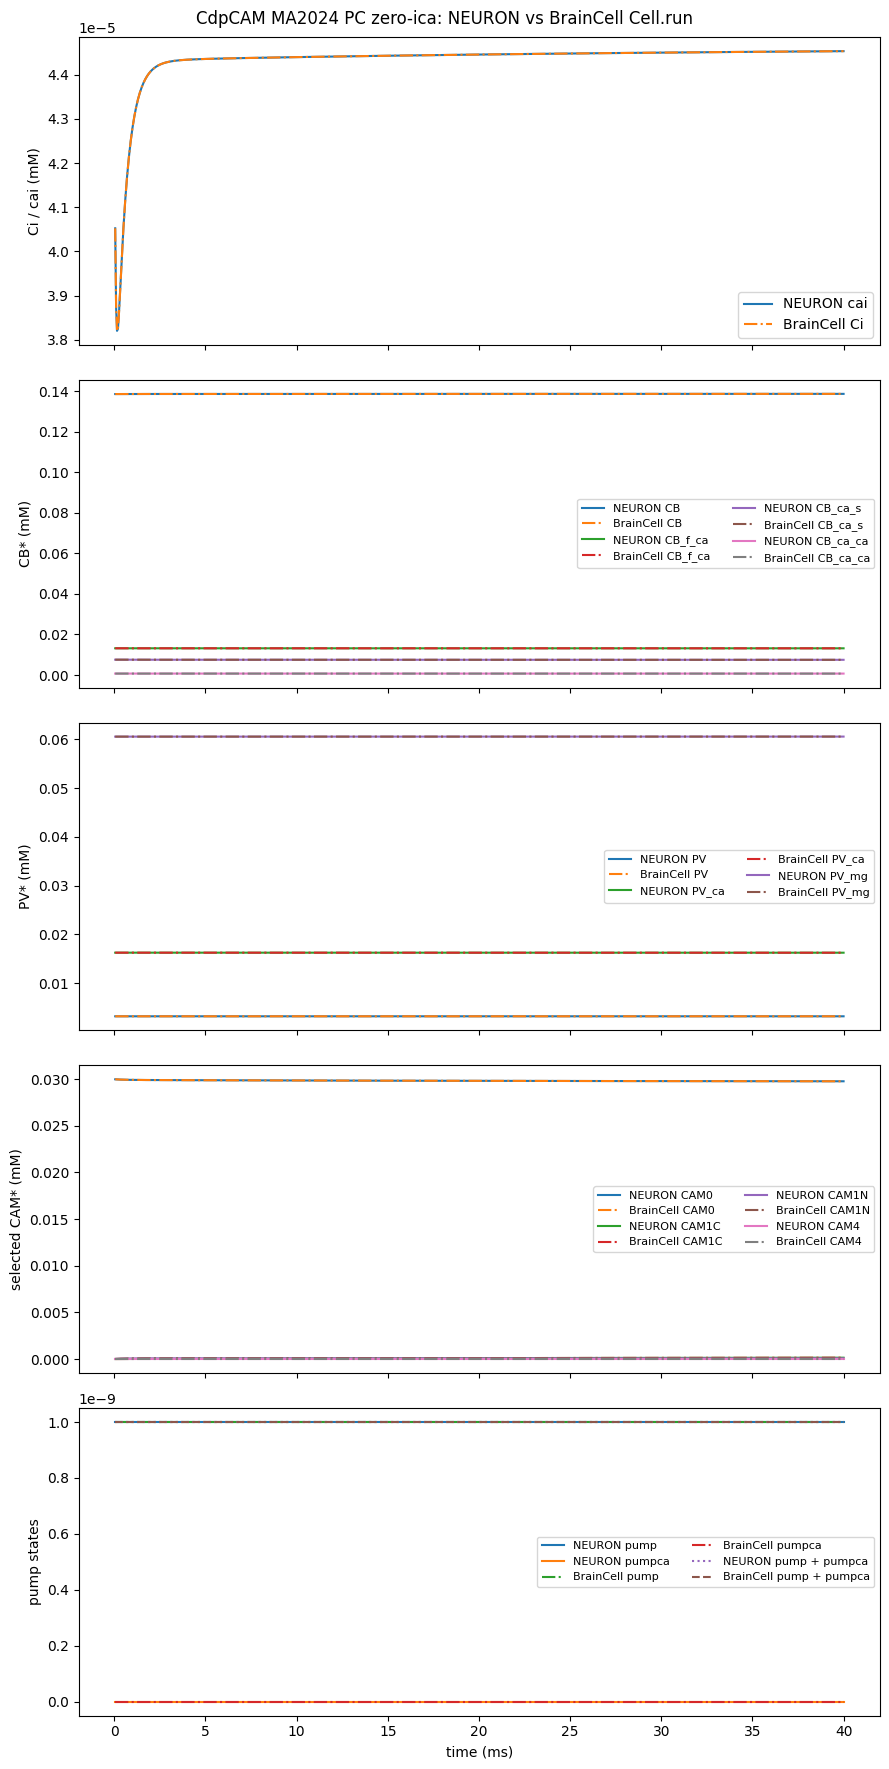

Per-field Cell.run vs NEURON error summary:
Ci {'mae': 1.0320453158812013e-12, 'rmse': 5.445298022512923e-12, 'max_abs': 7.274541973439691e-11}
pump {'mae': 6.683877843369886e-24, 'rmse': 1.2589781229852171e-23, 'max_abs': 6.307252170716836e-23}
pumpca {'mae': 6.741689106787268e-24, 'rmse': 1.2623066970543643e-23, 'max_abs': 6.325309974604894e-23}
CB {'mae': 1.1450660697409632e-11, 'rmse': 2.3140047233742292e-11, 'max_abs': 1.252808135010497e-10}
CB_f_ca {'mae': 2.987319289507462e-13, 'rmse': 4.927627163734717e-13, 'max_abs': 2.3664178255833335e-12}
CB_ca_s {'mae': 1.10584863445215e-11, 'rmse': 2.030517955964641e-11, 'max_abs': 1.0863573408903537e-10}
CB_ca_ca {'mae': 1.1543244756318654e-12, 'rmse': 2.840751547478266e-12, 'max_abs': 1.472288588787174e-11}
PV {'mae': 3.5388462017553466e-13, 'rmse': 7.508283915040629e-13, 'max_abs': 4.498840536215631e-12}
PV_ca {'mae': 1.4401287974641352e-12, 'rmse': 1.5698083564111021e-12, 'max_abs': 5.3020678125736964e-12}
PV_mg {'mae': 1.2194272588222

In [6]:
compare_t_ms = times_ms[1:]

def summarize_error(y, ref):
    y = np.asarray(y)
    ref = np.asarray(ref)
    n = min(len(y), len(ref))
    diff = y[:n] - ref[:n]
    return {
        'mae': float(np.mean(np.abs(diff))),
        'rmse': float(np.sqrt(np.mean(diff ** 2))),
        'max_abs': float(np.max(np.abs(diff))),
    }

error_summary = {}
for name in tracked_fields:
    neuron_cmp = neuron_data[name][1:]
    cell_cmp = cell_data[name]
    error_summary[name] = summarize_error(cell_cmp, neuron_cmp[:len(cell_cmp)])

fig, axes = plt.subplots(5, 1, figsize=(9, 18), sharex=True)

axes[0].plot(compare_t_ms, neuron_data['Ci'][1:], label='NEURON cai')
axes[0].plot(compare_t_ms[:len(cell_data['Ci'])], cell_data['Ci'], '-.', label='BrainCell Ci')
axes[0].set_ylabel('Ci / cai (mM)')
axes[0].legend()

for name in cb_fields:
    axes[1].plot(compare_t_ms, neuron_data[name][1:], label=f'NEURON {name}')
    axes[1].plot(compare_t_ms[:len(cell_data[name])], cell_data[name], '-.', label=f'BrainCell {name}')
axes[1].set_ylabel('CB* (mM)')
axes[1].legend(ncol=2, fontsize=8)

for name in pv_fields:
    axes[2].plot(compare_t_ms, neuron_data[name][1:], label=f'NEURON {name}')
    axes[2].plot(compare_t_ms[:len(cell_data[name])], cell_data[name], '-.', label=f'BrainCell {name}')
axes[2].set_ylabel('PV* (mM)')
axes[2].legend(ncol=2, fontsize=8)

for name in ['CAM0', 'CAM1C', 'CAM1N', 'CAM4']:
    axes[3].plot(compare_t_ms, neuron_data[name][1:], label=f'NEURON {name}')
    axes[3].plot(compare_t_ms[:len(cell_data[name])], cell_data[name], '-.', label=f'BrainCell {name}')
axes[3].set_ylabel('selected CAM* (mM)')
axes[3].legend(ncol=2, fontsize=8)

axes[4].plot(compare_t_ms, neuron_data['pump'][1:], label='NEURON pump')
axes[4].plot(compare_t_ms, neuron_data['pumpca'][1:], label='NEURON pumpca')
axes[4].plot(compare_t_ms[:len(cell_data['pump'])], cell_data['pump'], '-.', label='BrainCell pump')
axes[4].plot(compare_t_ms[:len(cell_data['pumpca'])], cell_data['pumpca'], '-.', label='BrainCell pumpca')
axes[4].plot(compare_t_ms, neuron_total[1:], ':', label='NEURON pump + pumpca')
axes[4].plot(compare_t_ms[:len(cell_total)], cell_total, '--', label='BrainCell pump + pumpca')
axes[4].set_xlabel('time (ms)')
axes[4].set_ylabel('pump states')
axes[4].legend(ncol=2, fontsize=8)

plt.suptitle('CdpCAM MA2024 PC zero-ica: NEURON vs BrainCell Cell.run')
plt.tight_layout()
plt.show()

print('Per-field Cell.run vs NEURON error summary:')
for name in tracked_fields:
    print(name, error_summary[name])

print('\nPump conserve drift:')
print('  NEURON:', float(np.max(np.abs(neuron_total - neuron_total[0]))))
print('  BrainCell Cell.run:', float(np.max(np.abs(cell_total - cell_total[0]))))

print('\nZero-ica check:')
print('  max |NEURON ica|:', float(np.max(np.abs(neuron_data['ica']))))

print('\nExtra CAM* end-state comparison:')
for name in ['CAM2C', 'CAM1N2C', 'CAM2N', 'CAM2N1C', 'CAM1C1N']:
    print(
        name,
        {
            'NEURON_end': float(neuron_data[name][-1]),
            'cell_end': float(cell_data[name][-1]),
        },
    )
